converged values:

$C_L = 0.286094$

$C_D = 0.007808$

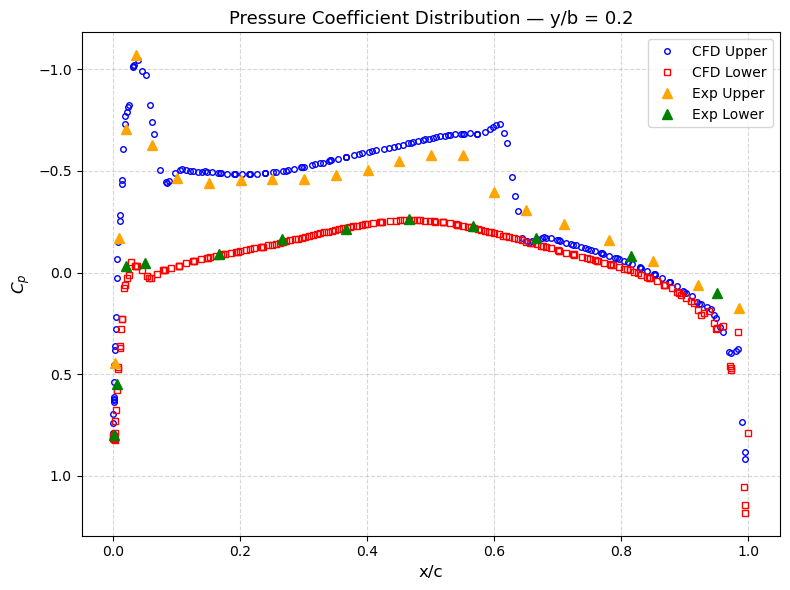

Saved Outputs/Cp_yb_020.pdf


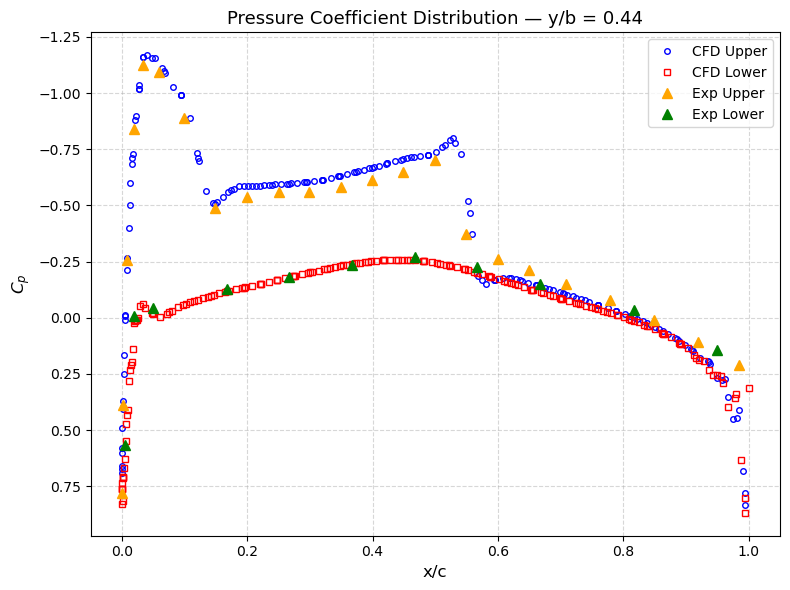

Saved Outputs/Cp_yb_044.pdf


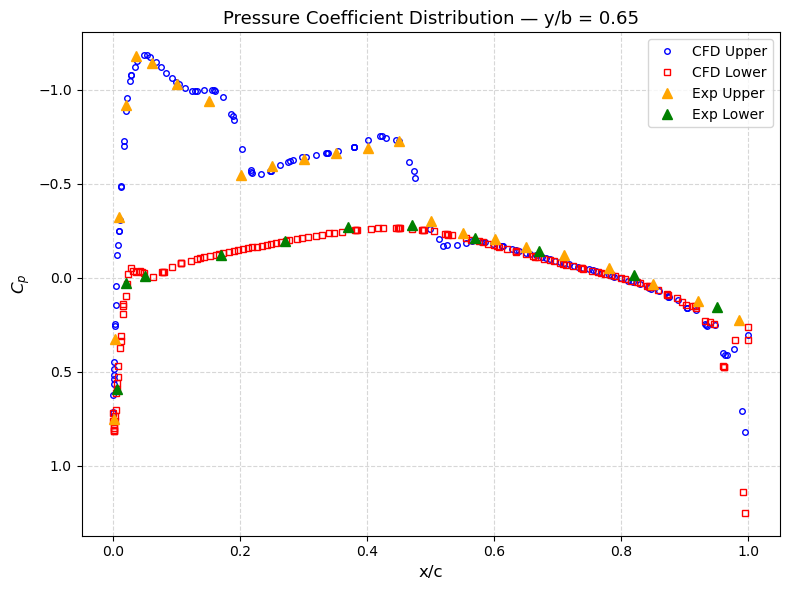

Saved Outputs/Cp_yb_065.pdf


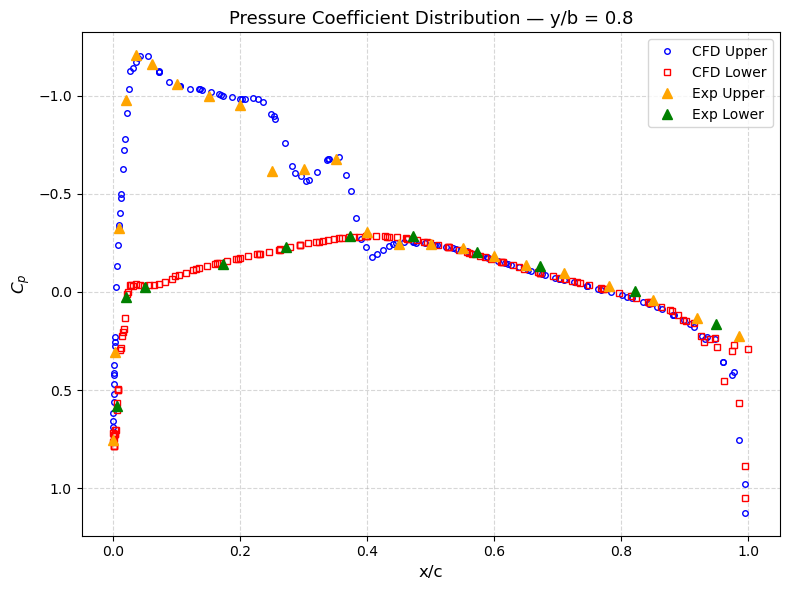

Saved Outputs/Cp_yb_080.pdf


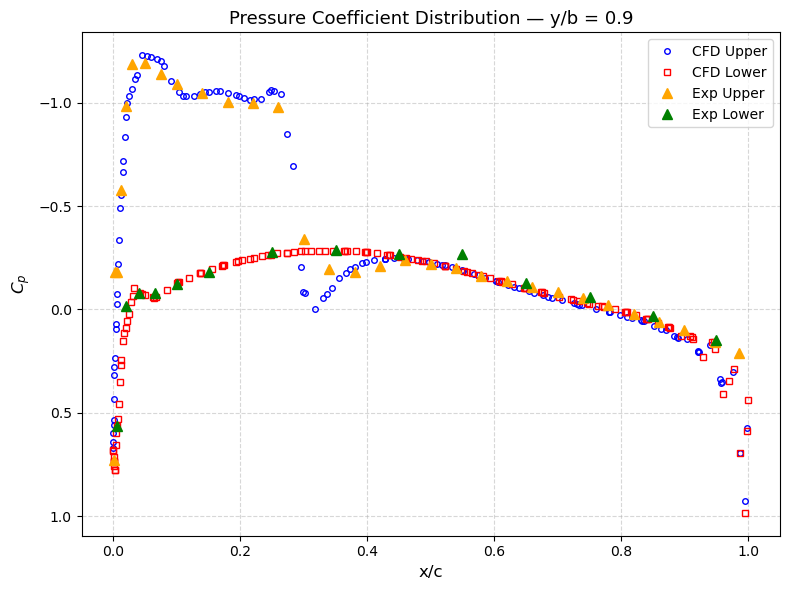

Saved Outputs/Cp_yb_090.pdf


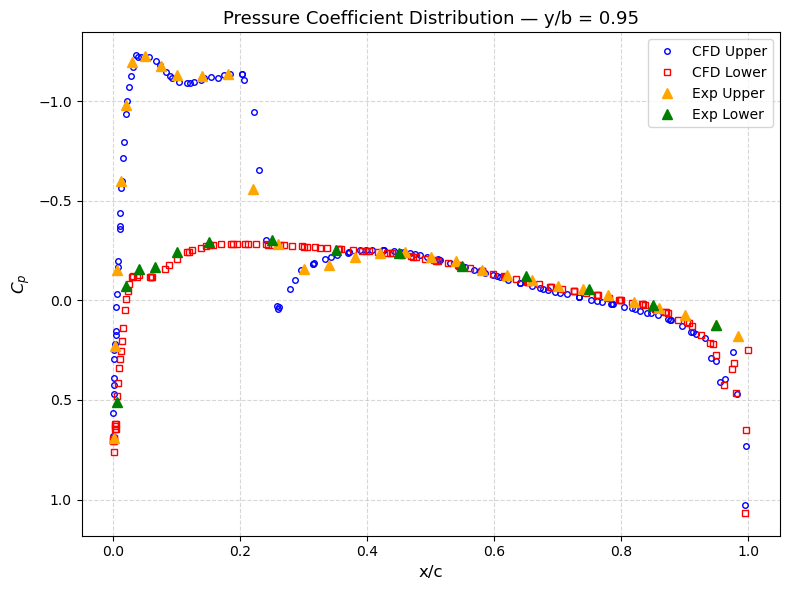

Saved Outputs/Cp_yb_095.pdf


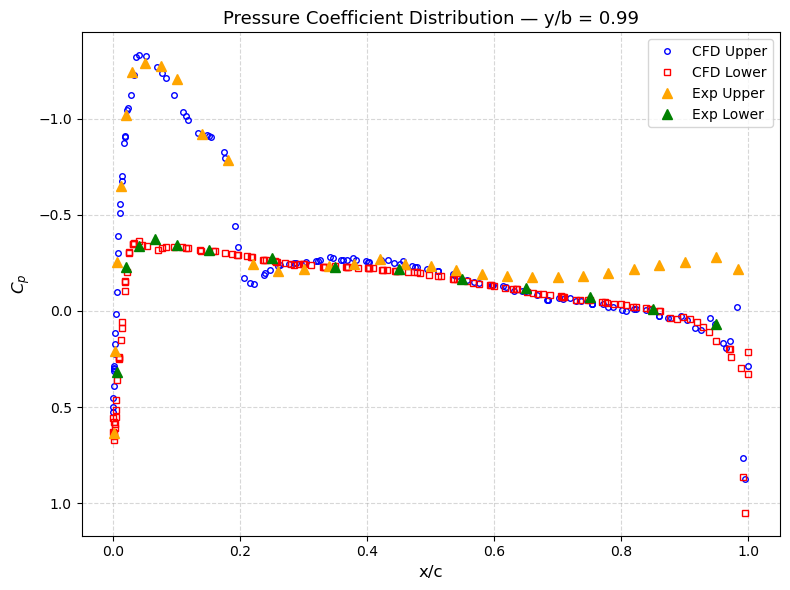

Saved Outputs/Cp_yb_099.pdf
All plots generated.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Configuration ---
data_dir = "data"
output_dir = "Outputs"
os.makedirs(output_dir, exist_ok=True)

# Spanwise stations: y/b label, CFD filename suffix, experimental file index
stations = [
    (0.20, "020", 1),
    (0.44, "044", 2),
    (0.65, "065", 3),
    (0.80, "080", 4),
    (0.90, "090", 5),
    (0.95, "095", 6),
    (0.99, "099", 7),
]

for yb, cfd_suffix, exp_idx in stations:
    fig, ax = plt.subplots(figsize=(8, 6))

    # --- Load CFD data ---
    cfd_file = os.path.join(data_dir, f"Cp-{cfd_suffix}.csv")
    cfd_data = np.genfromtxt(cfd_file, delimiter=",", skip_header=1)
    cp_cfd = cfd_data[:, 0]   # Pressure_Coefficient
    x_cfd  = cfd_data[:, 1]   # Points:0 (x coordinate)
    z_cfd  = cfd_data[:, 3]   # Points:2 (z coordinate, to separate upper/lower)

    # Compute local chord and x/c
    x_le = x_cfd.min()
    x_te = x_cfd.max()
    local_chord = x_te - x_le
    xc_cfd = (x_cfd - x_le) / local_chord

    # Separate upper (z >= 0) and lower (z < 0) surfaces
    upper = z_cfd >= 0
    lower = z_cfd < 0

    ax.plot(xc_cfd[upper], cp_cfd[upper], 'o', color='blue', markersize=4,
            label='CFD Upper', markerfacecolor='none')
    ax.plot(xc_cfd[lower], cp_cfd[lower], 's', color='red', markersize=4,
            label='CFD Lower', markerfacecolor='none')

    # --- Load experimental data ---
    exp_upper_file = os.path.join(data_dir, f"cp{exp_idx}u.ex")
    exp_lower_file = os.path.join(data_dir, f"cp{exp_idx}l.ex")

    if os.path.exists(exp_upper_file):
        exp_u = np.loadtxt(exp_upper_file)
        # File columns: x/c, -Cp  -->  Cp = -(-Cp) = second column negated
        ax.plot(exp_u[:, 0], -exp_u[:, 1], '^', color='orange', markersize=7,
                label='Exp Upper', markerfacecolor='orange')

    if os.path.exists(exp_lower_file):
        exp_l = np.loadtxt(exp_lower_file)
        ax.plot(exp_l[:, 0], -exp_l[:, 1], '^', color='green', markersize=7,
                label='Exp Lower', markerfacecolor='green')

    # --- Format plot ---
    ax.set_xlabel("x/c", fontsize=12)
    ax.set_ylabel(r"$C_p$", fontsize=12)
    ax.set_title(f"Pressure Coefficient Distribution — y/b = {yb}", fontsize=13)
    ax.invert_yaxis()
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()
    fig.savefig(os.path.join(output_dir, f"Cp_yb_{cfd_suffix}.pdf"), dpi=200)
    plt.show()
    print(f"Saved {output_dir}/Cp_yb_{cfd_suffix}.pdf")

print("All plots generated.")